In [23]:
import kagglehub
path = kagglehub.dataset_download("ericanacletoribeiro/cicids2017-cleaned-and-preprocessed")

Using Colab cache for faster access to the 'cicids2017-cleaned-and-preprocessed' dataset.


In [24]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/cicids2017-cleaned-and-preprocessed/cicids2017_cleaned.csv",
    low_memory=False
)

print(df.shape)
print(df["Attack Type"].value_counts())

(2520751, 53)
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [25]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/cicids2017-cleaned-and-preprocessed/cicids2017_cleaned.csv"
)

print(df.shape)

(2520751, 53)


In [26]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Attack Type"] = encoder.fit_transform(
    df["Attack Type"]
)

In [27]:
mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(
            encoder.classes_
        )
    )
)

print(mapping)

{'Bots': np.int64(0), 'Brute Force': np.int64(1), 'DDoS': np.int64(2), 'DoS': np.int64(3), 'Normal Traffic': np.int64(4), 'Port Scanning': np.int64(5), 'Web Attacks': np.int64(6)}


In [28]:
X = df.drop(
    "Attack Type",
    axis=1
)

y = df["Attack Type"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2016600, 52)
(504151, 52)


In [30]:
!pip install xgboost -q

In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=7,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)
xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=7, ...)

In [43]:
pred = xgb.predict(X_test)

In [45]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.9990974926162994
              precision    recall  f1-score   support

           0       0.97      0.69      0.81       389
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00     38749
           4       1.00      1.00      1.00    419012
           5       0.99      1.00      0.99     18139
           6       0.99      0.99      0.99       429

    accuracy                           1.00    504151
   macro avg       0.99      0.95      0.97    504151
weighted avg       1.00      1.00      1.00    504151



In [46]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

print(
    confusion_matrix(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.69      0.81       389
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00     38749
           4       1.00      1.00      1.00    419012
           5       0.99      1.00      0.99     18139
           6       0.99      0.99      0.99       429

    accuracy                           1.00    504151
   macro avg       0.99      0.95      0.97    504151
weighted avg       1.00      1.00      1.00    504151

[[   270      0      0      0    119      0      0]
 [     0   1829      0      0      1      0      0]
 [     0      0  25595      0      8      0      0]
 [     0      0      0  38724     19      3      3]
 [     9      0      2     83 418727    190      1]
 [     0      0      0      9      3  18125      2]
 [     0      0      0      1      2      0    426]]


In [47]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
50,Idle Max,0.150367
11,Bwd Packet Length Std,0.127157
49,Idle Mean,0.108524
44,act_data_pkt_fwd,0.059139
40,Average Packet Size,0.049564
14,Flow IAT Mean,0.047169
13,Flow Packets/s,0.046740
10,Bwd Packet Length Mean,0.046415
12,Flow Bytes/s,0.041410
3,Total Length of Fwd Packets,0.039588


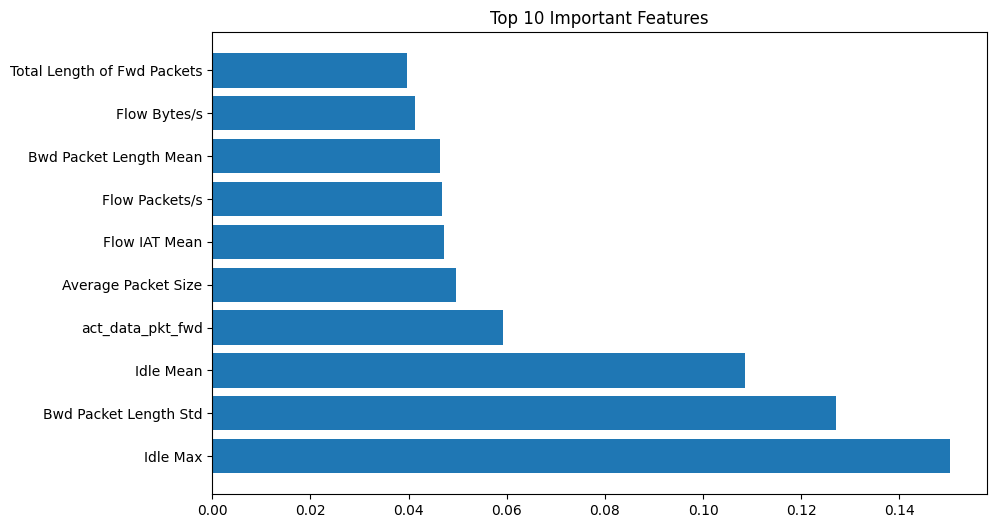

In [48]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [77]:
import joblib

joblib.dump(xgb, "xgboost_multiclass.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']